In [2]:
# ============================================================
# CELL 1: SETUP AND LOAD DATASET
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
import re
from tqdm import tqdm
import random

try:
    import tiktoken
    TOKENIZER = tiktoken.get_encoding("cl100k_base")
    HAS_TIKTOKEN = True
except ImportError:
    HAS_TIKTOKEN = False
    print("tiktoken not installed. Using char-based approximation.")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Config
USE_SAMPLE = False
DATASET_PATH = "sharedgpt_sample.json" if USE_SAMPLE else "ShareGPT_V3_unfiltered_cleaned_split.json"

print(f"Loading: {DATASET_PATH}")
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
print(f"Loaded {len(data):,} conversations")

def count_tokens(text: str) -> int:
    if HAS_TIKTOKEN:
        return len(TOKENIZER.encode(text))
    return len(text) // 4

def analyze_conversation(conv: Dict) -> Dict:
    messages = conv.get('conversations', [])
    human_msgs = [m for m in messages if m.get('from') == 'human']
    gpt_msgs = [m for m in messages if m.get('from') == 'gpt']
    human_texts = [m.get('value', '') for m in human_msgs]
    gpt_texts = [m.get('value', '') for m in gpt_msgs]
    return {
        'id': conv.get('id', ''),
        'num_turns': len(messages),
        'num_human_turns': len(human_msgs),
        'num_gpt_turns': len(gpt_msgs),
        'human_token_total': sum(count_tokens(t) for t in human_texts),
        'gpt_token_total': sum(count_tokens(t) for t in gpt_texts),
        'human_texts': human_texts,
        'gpt_texts': gpt_texts,
        'all_messages': messages
    }

print("Analyzing...")
conv_stats = [analyze_conversation(conv) for conv in tqdm(data)]
df = pd.DataFrame([{k: v for k, v in s.items() if k not in ['human_texts', 'gpt_texts', 'all_messages']} for s in conv_stats])
print(f"Ready: {len(df):,} conversations")

tiktoken not installed. Using char-based approximation.
Loading: ShareGPT_V3_unfiltered_cleaned_split.json
Loaded 94,145 conversations
Analyzing...


100%|██████████| 94145/94145 [00:02<00:00, 43625.95it/s]


Ready: 94,145 conversations


LENGTH ANALYSIS

[PER CONVERSATION]
Total: 94,145 convs, 702,151 turns (Human: 333,941, GPT: 367,790)
Turns/conv: mean=7.5, median=6, std=5.8
Human tokens/conv: mean=300.5, median=101
GPT tokens/conv: mean=1316.1, median=1277

[PER MESSAGE]
Human (333,941): mean=84.7, median=19.0, P90=138, P99=1353
GPT (367,790): mean=336.9, median=310.0, P90=655, P99=961

[LENGTH BUCKETS]
Human: {'0-50': '256,750 (76.9%)', '50-100': '33,825 (10.1%)', '100-200': '18,188 (5.4%)', '200-500': '13,973 (4.2%)', '500-1000': '5,956 (1.8%)', '1000-2000': '3,525 (1.1%)', '2000-5000': '1,655 (0.5%)', '5000-+': '69 (0.0%)'}
GPT: {'0-50': '32,955 (9.0%)', '50-100': '24,467 (6.7%)', '100-200': '56,372 (15.3%)', '200-500': '176,156 (47.9%)', '500-1000': '75,516 (20.5%)', '1000-2000': '2,304 (0.6%)', '2000-5000': '11 (0.0%)', '5000-+': '9 (0.0%)'}

[PER TURN POSITION]
Turn 1: Human(n=92,837, mean=184) | GPT(n=93,481, mean=376)
Turn 2: Human(n=69,263, mean=61) | GPT(n=73,563, mean=365)
Turn 3: Human(n=53,210, mean=49)

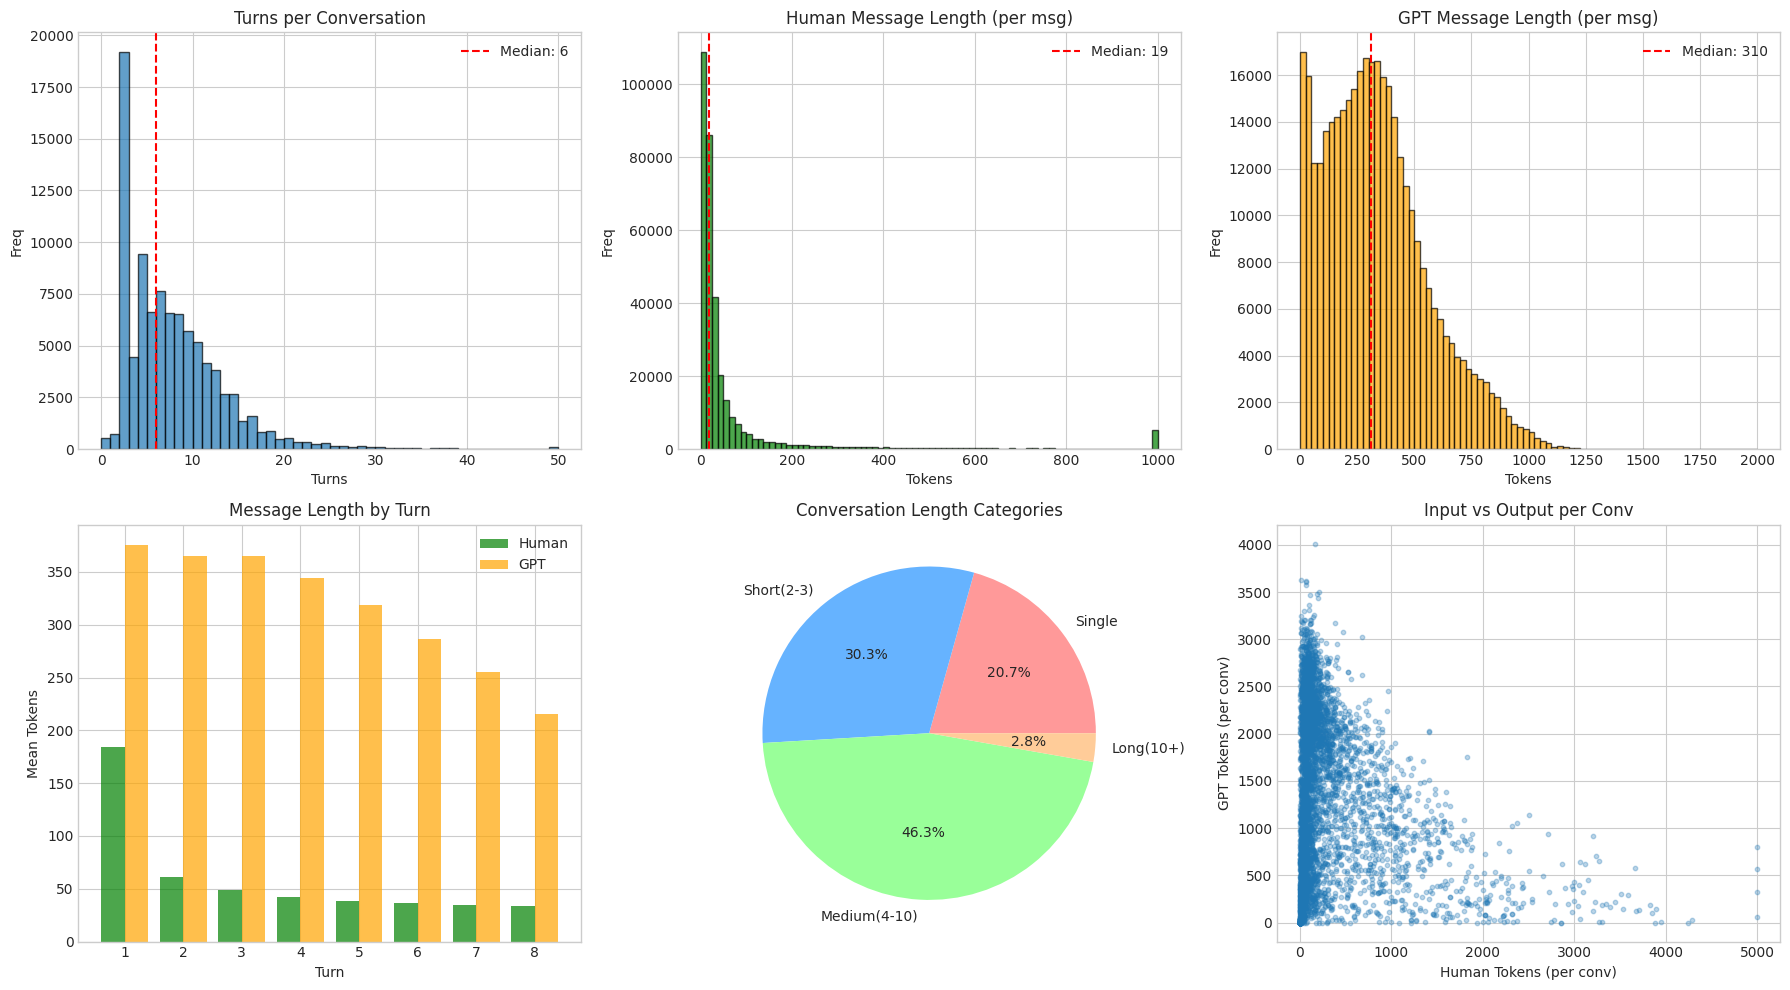

In [3]:
# ============================================================
# CELL 2: LENGTH ANALYSIS (Per Conv, Per Request, Per Turn, Multi-turn)
# ============================================================

# --- Collect data ---
human_msg_lengths, gpt_msg_lengths = [], []
for s in conv_stats:
    human_msg_lengths.extend([count_tokens(t) for t in s['human_texts']])
    gpt_msg_lengths.extend([count_tokens(t) for t in s['gpt_texts']])

human_by_turn, gpt_by_turn = defaultdict(list), defaultdict(list)
for s in conv_stats:
    h_idx, g_idx = 0, 0
    for msg in s['all_messages']:
        tokens = count_tokens(msg.get('value', ''))
        if msg.get('from') == 'human' and h_idx < 10:
            human_by_turn[h_idx].append(tokens)
            h_idx += 1
        elif msg.get('from') == 'gpt' and g_idx < 10:
            gpt_by_turn[g_idx].append(tokens)
            g_idx += 1

turn_counts = df['num_turns'].values
single_turn = sum(1 for t in turn_counts if t == 2)
short_conv = sum(1 for t in turn_counts if 2 < t <= 6)
medium_conv = sum(1 for t in turn_counts if 6 < t <= 20)
long_conv = sum(1 for t in turn_counts if t > 20)
total = len(turn_counts)

def bucket_lengths(lengths, buckets=[0, 50, 100, 200, 500, 1000, 2000, 5000, float('inf')]):
    counts = Counter()
    for l in lengths:
        for i in range(len(buckets)-1):
            if buckets[i] <= l < buckets[i+1]:
                counts[f"{buckets[i]}-{buckets[i+1] if buckets[i+1] != float('inf') else '+'}"] += 1
                break
    return counts

# --- Print Stats ---
print("=" * 80)
print("LENGTH ANALYSIS")
print("=" * 80)

print(f"\n[PER CONVERSATION]")
print(f"Total: {len(df):,} convs, {df['num_turns'].sum():,} turns (Human: {df['num_human_turns'].sum():,}, GPT: {df['num_gpt_turns'].sum():,})")
print(f"Turns/conv: mean={df['num_turns'].mean():.1f}, median={df['num_turns'].median():.0f}, std={df['num_turns'].std():.1f}")
print(f"Human tokens/conv: mean={df['human_token_total'].mean():.1f}, median={df['human_token_total'].median():.0f}")
print(f"GPT tokens/conv: mean={df['gpt_token_total'].mean():.1f}, median={df['gpt_token_total'].median():.0f}")

print(f"\n[PER MESSAGE]")
print(f"Human ({len(human_msg_lengths):,}): mean={np.mean(human_msg_lengths):.1f}, median={np.median(human_msg_lengths):.1f}, P90={np.percentile(human_msg_lengths,90):.0f}, P99={np.percentile(human_msg_lengths,99):.0f}")
print(f"GPT ({len(gpt_msg_lengths):,}): mean={np.mean(gpt_msg_lengths):.1f}, median={np.median(gpt_msg_lengths):.1f}, P90={np.percentile(gpt_msg_lengths,90):.0f}, P99={np.percentile(gpt_msg_lengths,99):.0f}")

print(f"\n[LENGTH BUCKETS]")
print("Human:", {k: f"{v:,} ({v/len(human_msg_lengths)*100:.1f}%)" for k,v in sorted(bucket_lengths(human_msg_lengths).items(), key=lambda x: int(x[0].split('-')[0]))})
print("GPT:", {k: f"{v:,} ({v/len(gpt_msg_lengths)*100:.1f}%)" for k,v in sorted(bucket_lengths(gpt_msg_lengths).items(), key=lambda x: int(x[0].split('-')[0]))})

print(f"\n[PER TURN POSITION]")
for i in range(min(5, len(human_by_turn))):
    print(f"Turn {i+1}: Human(n={len(human_by_turn[i]):,}, mean={np.mean(human_by_turn[i]):.0f}) | GPT(n={len(gpt_by_turn[i]):,}, mean={np.mean(gpt_by_turn[i]):.0f})")

print(f"\n[MULTI-TURN CONVERSATION LENGTH]")
print(f"Single-turn (1 exchange): {single_turn:,} ({single_turn/total*100:.1f}%)")
print(f"Short (2-3 exchanges): {short_conv:,} ({short_conv/total*100:.1f}%)")
print(f"Medium (4-10 exchanges): {medium_conv:,} ({medium_conv/total*100:.1f}%)")
print(f"Long (10+ exchanges): {long_conv:,} ({long_conv/total*100:.1f}%)")
print(f"Multi-turn total: {total-single_turn:,} ({(total-single_turn)/total*100:.1f}%)")

# --- Visualizations ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Per-conv, per-message distributions
axes[0,0].hist(df['num_turns'].clip(upper=50), bins=50, edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['num_turns'].median(), color='red', linestyle='--', label=f'Median: {df["num_turns"].median():.0f}')
axes[0,0].set_xlabel('Turns'); axes[0,0].set_ylabel('Freq'); axes[0,0].set_title('Turns per Conversation'); axes[0,0].legend()

axes[0,1].hist(np.clip(human_msg_lengths, 0, 1000), bins=80, alpha=0.7, color='green', edgecolor='black')
axes[0,1].axvline(np.median(human_msg_lengths), color='red', linestyle='--', label=f'Median: {np.median(human_msg_lengths):.0f}')
axes[0,1].set_xlabel('Tokens'); axes[0,1].set_ylabel('Freq'); axes[0,1].set_title('Human Message Length (per msg)'); axes[0,1].legend()

axes[0,2].hist(np.clip(gpt_msg_lengths, 0, 2000), bins=80, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].axvline(np.median(gpt_msg_lengths), color='red', linestyle='--', label=f'Median: {np.median(gpt_msg_lengths):.0f}')
axes[0,2].set_xlabel('Tokens'); axes[0,2].set_ylabel('Freq'); axes[0,2].set_title('GPT Message Length (per msg)'); axes[0,2].legend()

# Row 2: Per-turn, multi-turn categories
max_t = 8
turns = range(1, max_t+1)
h_means = [np.mean(human_by_turn[t]) if human_by_turn[t] else 0 for t in range(max_t)]
g_means = [np.mean(gpt_by_turn[t]) if gpt_by_turn[t] else 0 for t in range(max_t)]
x = np.arange(max_t)
axes[1,0].bar(x-0.2, h_means, 0.4, label='Human', color='green', alpha=0.7)
axes[1,0].bar(x+0.2, g_means, 0.4, label='GPT', color='orange', alpha=0.7)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(turns)
axes[1,0].set_xlabel('Turn'); axes[1,0].set_ylabel('Mean Tokens'); axes[1,0].set_title('Message Length by Turn'); axes[1,0].legend()

axes[1,1].pie([single_turn, short_conv, medium_conv, long_conv], 
              labels=['Single', 'Short(2-3)', 'Medium(4-10)', 'Long(10+)'],
              autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1,1].set_title('Conversation Length Categories')

sample_df = df.sample(n=min(5000, len(df)), random_state=42)
axes[1,2].scatter(sample_df['human_token_total'].clip(upper=5000), sample_df['gpt_token_total'].clip(upper=10000), alpha=0.3, s=10)
axes[1,2].set_xlabel('Human Tokens (per conv)'); axes[1,2].set_ylabel('GPT Tokens (per conv)'); axes[1,2].set_title('Input vs Output per Conv')

plt.tight_layout()
plt.savefig('length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Analyzing per-turn prefix sharing within conversations...


  8%|▊         | 7232/94145 [00:00<00:02, 36154.42it/s]

100%|██████████| 94145/94145 [00:03<00:00, 27537.19it/s]



PREFIX SHARING ANALYSIS (Per-Turn within Conversation)

[OVERALL STATISTICS]
Multi-turn conversations analyzed: 69,263
Total LLM requests with prefix: 241,104
Prefix hit ratio: mean=0.9461, median=0.9806
Prefix tokens: mean=1086, median=1049
Per-conversation avg prefix ratio: mean=0.9347, median=0.9707

[PREFIX HIT RATIO BY TURN POSITION]
(Turn 1 has no prefix, Turn 2+ shows prefix from accumulated history)
  Turn 2: n=69,263, prefix_ratio=0.902, prefix_tokens=   652, prompt_size=   713
  Turn 3: n=53,210, prefix_ratio=0.947, prefix_tokens=   981, prompt_size=  1030
  Turn 4: n=38,998, prefix_ratio=0.964, prefix_tokens=  1228, prompt_size=  1270
  Turn 5: n=26,730, prefix_ratio=0.971, prefix_tokens=  1398, prompt_size=  1436
  Turn 6: n=17,384, prefix_ratio=0.973, prefix_tokens=  1497, prompt_size=  1534
  Turn 7: n=10,913, prefix_ratio=0.976, prefix_tokens=  1540, prompt_size=  1574
  Turn 8: n= 6,852, prefix_ratio=0.977, prefix_tokens=  1540, prompt_size=  1573
  Turn 9: n= 4,452, p

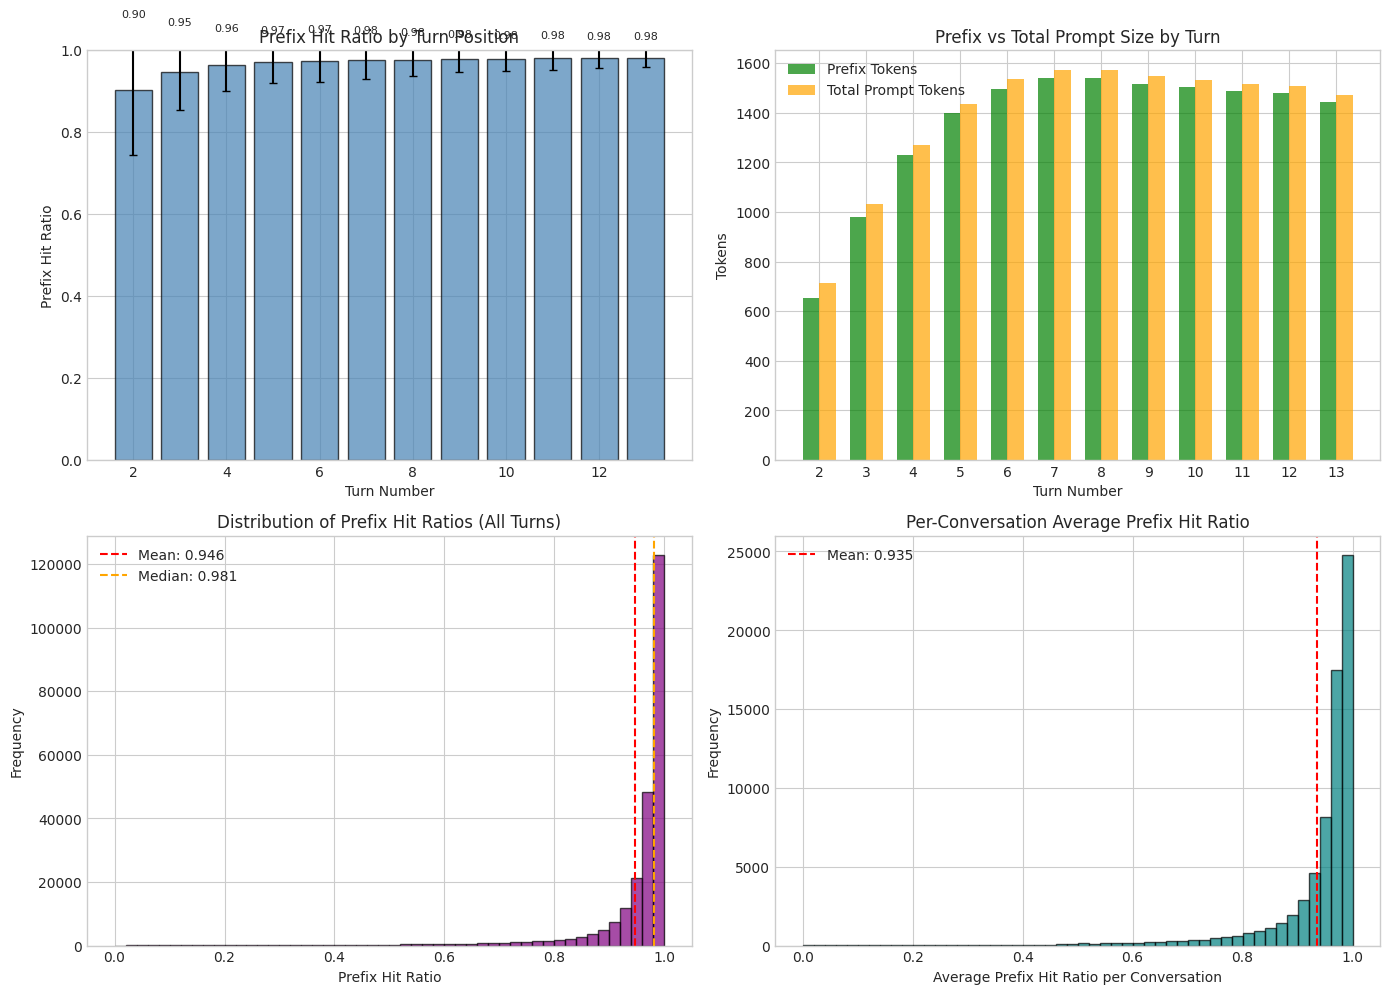


[EXAMPLE: Prefix Growth in Long Conversations]
Conversation with 6 turns:
  Turn 1: prompt_tokens=47, prefix_ratio=0 (no prefix)
  Turn 2: prompt_tokens=418, prefix_tokens=371, prefix_ratio=0.888
  Turn 3: prompt_tokens=853, prefix_tokens=832, prefix_ratio=0.975
  Turn 4: prompt_tokens=1254, prefix_tokens=1210, prefix_ratio=0.965
  Turn 5: prompt_tokens=1668, prefix_tokens=1655, prefix_ratio=0.992
  Turn 6: prompt_tokens=2092, prefix_tokens=2079, prefix_ratio=0.994


In [4]:
# ============================================================
# CELL 3: PREFIX SHARING ANALYSIS (Per-Turn within Conversation)
# ============================================================
# In multi-turn conversations, each request to LLM includes conversation history:
#   Turn 1 prompt: [human_1]
#   Turn 2 prompt: [human_1, gpt_1, human_2]  -> shares prefix with turn 1
#   Turn 3 prompt: [human_1, gpt_1, human_2, gpt_2, human_3] -> shares more prefix
# Prefix hit ratio grows as conversation progresses!

def analyze_prefix_sharing_per_conversation(stats: Dict) -> Dict:
    """
    Analyze prefix sharing within a single conversation.
    Simulates actual LLM prompts at each turn and calculates prefix hit ratio.
    """
    messages = stats['all_messages']
    if len(messages) < 2:
        return None
    
    # Build prompts for each turn (human message triggers LLM call)
    prompts = []  # Each element is the full prompt sent to LLM at that turn
    prompt_tokens = []  # Token count for each prompt
    
    accumulated = ""
    accumulated_tokens = 0
    human_turn_idx = 0
    
    for i, msg in enumerate(messages):
        role = msg.get('from', '')
        text = msg.get('value', '')
        tokens = count_tokens(text)
        
        if role == 'human':
            # This triggers an LLM call - record the full prompt
            current_prompt = accumulated + text
            current_tokens = accumulated_tokens + tokens
            prompts.append(current_prompt)
            prompt_tokens.append(current_tokens)
            human_turn_idx += 1
            # Add to accumulated for next turn
            accumulated = current_prompt
            accumulated_tokens = current_tokens
        elif role == 'gpt':
            # GPT response gets added to history for next turn
            accumulated += text
            accumulated_tokens += tokens
    
    if len(prompts) < 2:
        return None
    
    # Calculate prefix sharing between consecutive turns
    prefix_hit_ratios = []  # ratio of shared prefix to current prompt
    prefix_hit_tokens = []  # absolute tokens shared
    new_tokens_per_turn = []  # new tokens added at each turn
    
    for i in range(1, len(prompts)):
        prev_tokens = prompt_tokens[i-1]
        curr_tokens = prompt_tokens[i]
        
        # The prefix shared is exactly the previous prompt (since it's accumulated)
        # But we need to account for the GPT response that was added
        # Actually, prev prompt tokens are fully contained in current prompt
        # So shared_prefix = prev_prompt_tokens + gpt_response_tokens (up to current human msg)
        
        # Simpler: shared prefix = everything before current human message
        # = curr_tokens - tokens_of_current_human_message
        if i < len(stats['human_texts']):
            current_human_tokens = count_tokens(stats['human_texts'][i])
        else:
            current_human_tokens = 0
        
        shared_prefix_tokens = curr_tokens - current_human_tokens
        prefix_hit_ratio = shared_prefix_tokens / curr_tokens if curr_tokens > 0 else 0
        
        prefix_hit_ratios.append(prefix_hit_ratio)
        prefix_hit_tokens.append(shared_prefix_tokens)
        new_tokens_per_turn.append(current_human_tokens)
    
    return {
        'num_turns': len(prompts),
        'prompt_tokens': prompt_tokens,
        'prefix_hit_ratios': prefix_hit_ratios,
        'prefix_hit_tokens': prefix_hit_tokens,
        'new_tokens_per_turn': new_tokens_per_turn,
        'avg_prefix_hit_ratio': np.mean(prefix_hit_ratios) if prefix_hit_ratios else 0
    }

# Analyze all conversations
print("Analyzing per-turn prefix sharing within conversations...")
prefix_results = []
for s in tqdm(conv_stats):
    result = analyze_prefix_sharing_per_conversation(s)
    if result:
        prefix_results.append(result)

# Aggregate by turn position
prefix_by_turn = defaultdict(list)  # turn_idx -> list of prefix_hit_ratios at that turn
tokens_by_turn = defaultdict(list)  # turn_idx -> list of prefix tokens at that turn
prompt_size_by_turn = defaultdict(list)  # turn_idx -> list of total prompt tokens

for r in prefix_results:
    for i, ratio in enumerate(r['prefix_hit_ratios']):
        turn_idx = i + 2  # Turn 2, 3, 4, ... (turn 1 has no prefix)
        prefix_by_turn[turn_idx].append(ratio)
        tokens_by_turn[turn_idx].append(r['prefix_hit_tokens'][i])
        prompt_size_by_turn[turn_idx].append(r['prompt_tokens'][i+1])

# Overall statistics
all_prefix_ratios = [ratio for r in prefix_results for ratio in r['prefix_hit_ratios']]
all_prefix_tokens = [t for r in prefix_results for t in r['prefix_hit_tokens']]
conv_avg_ratios = [r['avg_prefix_hit_ratio'] for r in prefix_results]

print("\n" + "=" * 80)
print("PREFIX SHARING ANALYSIS (Per-Turn within Conversation)")
print("=" * 80)

print(f"\n[OVERALL STATISTICS]")
print(f"Multi-turn conversations analyzed: {len(prefix_results):,}")
print(f"Total LLM requests with prefix: {len(all_prefix_ratios):,}")
print(f"Prefix hit ratio: mean={np.mean(all_prefix_ratios):.4f}, median={np.median(all_prefix_ratios):.4f}")
print(f"Prefix tokens: mean={np.mean(all_prefix_tokens):.0f}, median={np.median(all_prefix_tokens):.0f}")
print(f"Per-conversation avg prefix ratio: mean={np.mean(conv_avg_ratios):.4f}, median={np.median(conv_avg_ratios):.4f}")

print(f"\n[PREFIX HIT RATIO BY TURN POSITION]")
print("(Turn 1 has no prefix, Turn 2+ shows prefix from accumulated history)")
for turn in sorted(prefix_by_turn.keys())[:10]:
    ratios = prefix_by_turn[turn]
    tokens = tokens_by_turn[turn]
    prompt_sizes = prompt_size_by_turn[turn]
    print(f"  Turn {turn}: n={len(ratios):>6,}, prefix_ratio={np.mean(ratios):.3f}, "
          f"prefix_tokens={np.mean(tokens):>6.0f}, prompt_size={np.mean(prompt_sizes):>6.0f}")

print(f"\n[INTERPRETATION]")
print("- Prefix hit ratio increases with turn number (more history accumulated)")
print("- At turn K, prefix = all previous turns' content (human + gpt messages)")
print("- High prefix ratio means most of the prompt is reusable from KV cache")

# --- Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Prefix hit ratio by turn position
ax1 = axes[0, 0]
turns = sorted(prefix_by_turn.keys())[:12]
means = [np.mean(prefix_by_turn[t]) for t in turns]
stds = [np.std(prefix_by_turn[t]) for t in turns]
ax1.bar(turns, means, yerr=stds, capsize=3, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Turn Number')
ax1.set_ylabel('Prefix Hit Ratio')
ax1.set_title('Prefix Hit Ratio by Turn Position')
ax1.set_ylim(0, 1)
for i, (t, m) in enumerate(zip(turns, means)):
    ax1.text(t, m + stds[i] + 0.02, f'{m:.2f}', ha='center', fontsize=8)

# Plot 2: Prefix tokens by turn position
ax2 = axes[0, 1]
prefix_means = [np.mean(tokens_by_turn[t]) for t in turns]
prompt_means = [np.mean(prompt_size_by_turn[t]) for t in turns]
x = np.arange(len(turns))
width = 0.35
ax2.bar(x - width/2, prefix_means, width, label='Prefix Tokens', color='green', alpha=0.7)
ax2.bar(x + width/2, prompt_means, width, label='Total Prompt Tokens', color='orange', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(turns)
ax2.set_xlabel('Turn Number')
ax2.set_ylabel('Tokens')
ax2.set_title('Prefix vs Total Prompt Size by Turn')
ax2.legend()

# Plot 3: Distribution of prefix hit ratios (all turns combined)
ax3 = axes[1, 0]
ax3.hist(all_prefix_ratios, bins=50, edgecolor='black', alpha=0.7, color='purple')
ax3.axvline(np.mean(all_prefix_ratios), color='red', linestyle='--', 
            label=f'Mean: {np.mean(all_prefix_ratios):.3f}')
ax3.axvline(np.median(all_prefix_ratios), color='orange', linestyle='--', 
            label=f'Median: {np.median(all_prefix_ratios):.3f}')
ax3.set_xlabel('Prefix Hit Ratio')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Prefix Hit Ratios (All Turns)')
ax3.legend()

# Plot 4: Per-conversation average prefix ratio distribution
ax4 = axes[1, 1]
ax4.hist(conv_avg_ratios, bins=50, edgecolor='black', alpha=0.7, color='teal')
ax4.axvline(np.mean(conv_avg_ratios), color='red', linestyle='--', 
            label=f'Mean: {np.mean(conv_avg_ratios):.3f}')
ax4.set_xlabel('Average Prefix Hit Ratio per Conversation')
ax4.set_ylabel('Frequency')
ax4.set_title('Per-Conversation Average Prefix Hit Ratio')
ax4.legend()

plt.tight_layout()
plt.savefig('prefix_sharing.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional: Show how prefix ratio grows within individual conversations
print(f"\n[EXAMPLE: Prefix Growth in Long Conversations]")
long_convs = [r for r in prefix_results if r['num_turns'] >= 6]
if long_convs:
    example = long_convs[0]
    print(f"Conversation with {example['num_turns']} turns:")
    print(f"  Turn 1: prompt_tokens={example['prompt_tokens'][0]}, prefix_ratio=0 (no prefix)")
    for i, ratio in enumerate(example['prefix_hit_ratios']):
        turn = i + 2
        print(f"  Turn {turn}: prompt_tokens={example['prompt_tokens'][i+1]}, "
              f"prefix_tokens={example['prefix_hit_tokens'][i]}, prefix_ratio={ratio:.3f}")

Classifying prompts with enhanced patterns...


Classifying: 100%|██████████| 94145/94145 [17:54<00:00, 87.62it/s]  


PROMPT TYPE CLASSIFICATION (Enhanced)
Total: 94,145 | Multi-category: 54,840 (58.3%)

Category Distribution (prompts can have multiple categories):
                coding:   30,439 ( 32.3%)
               writing:   28,187 ( 29.9%)
    question_answering:   27,551 ( 29.3%)
           explanation:   22,970 ( 24.4%)
           instruction:   18,607 ( 19.8%)
              business:   15,671 ( 16.6%)
          conversation:   14,455 ( 15.4%)
         brainstorming:   14,228 ( 15.1%)
              analysis:   14,023 ( 14.9%)
                 other:   12,983 ( 13.8%)
                  math:   12,649 ( 13.4%)
              creative:   10,608 ( 11.3%)
           translation:    5,064 (  5.4%)

OUTPUT LENGTH ANALYSIS BY CATEGORY

[OUTPUT LENGTH STATS BY PRIMARY CATEGORY]
Category                Count   Mean Out     Median        Std      P25      P75      P90
------------------------------------------------------------------------------------------------
math                    5,169      327.8

/tmp/ipykernel_2817722/215324253.py:345: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=cats_by_count, patch_artist=True)


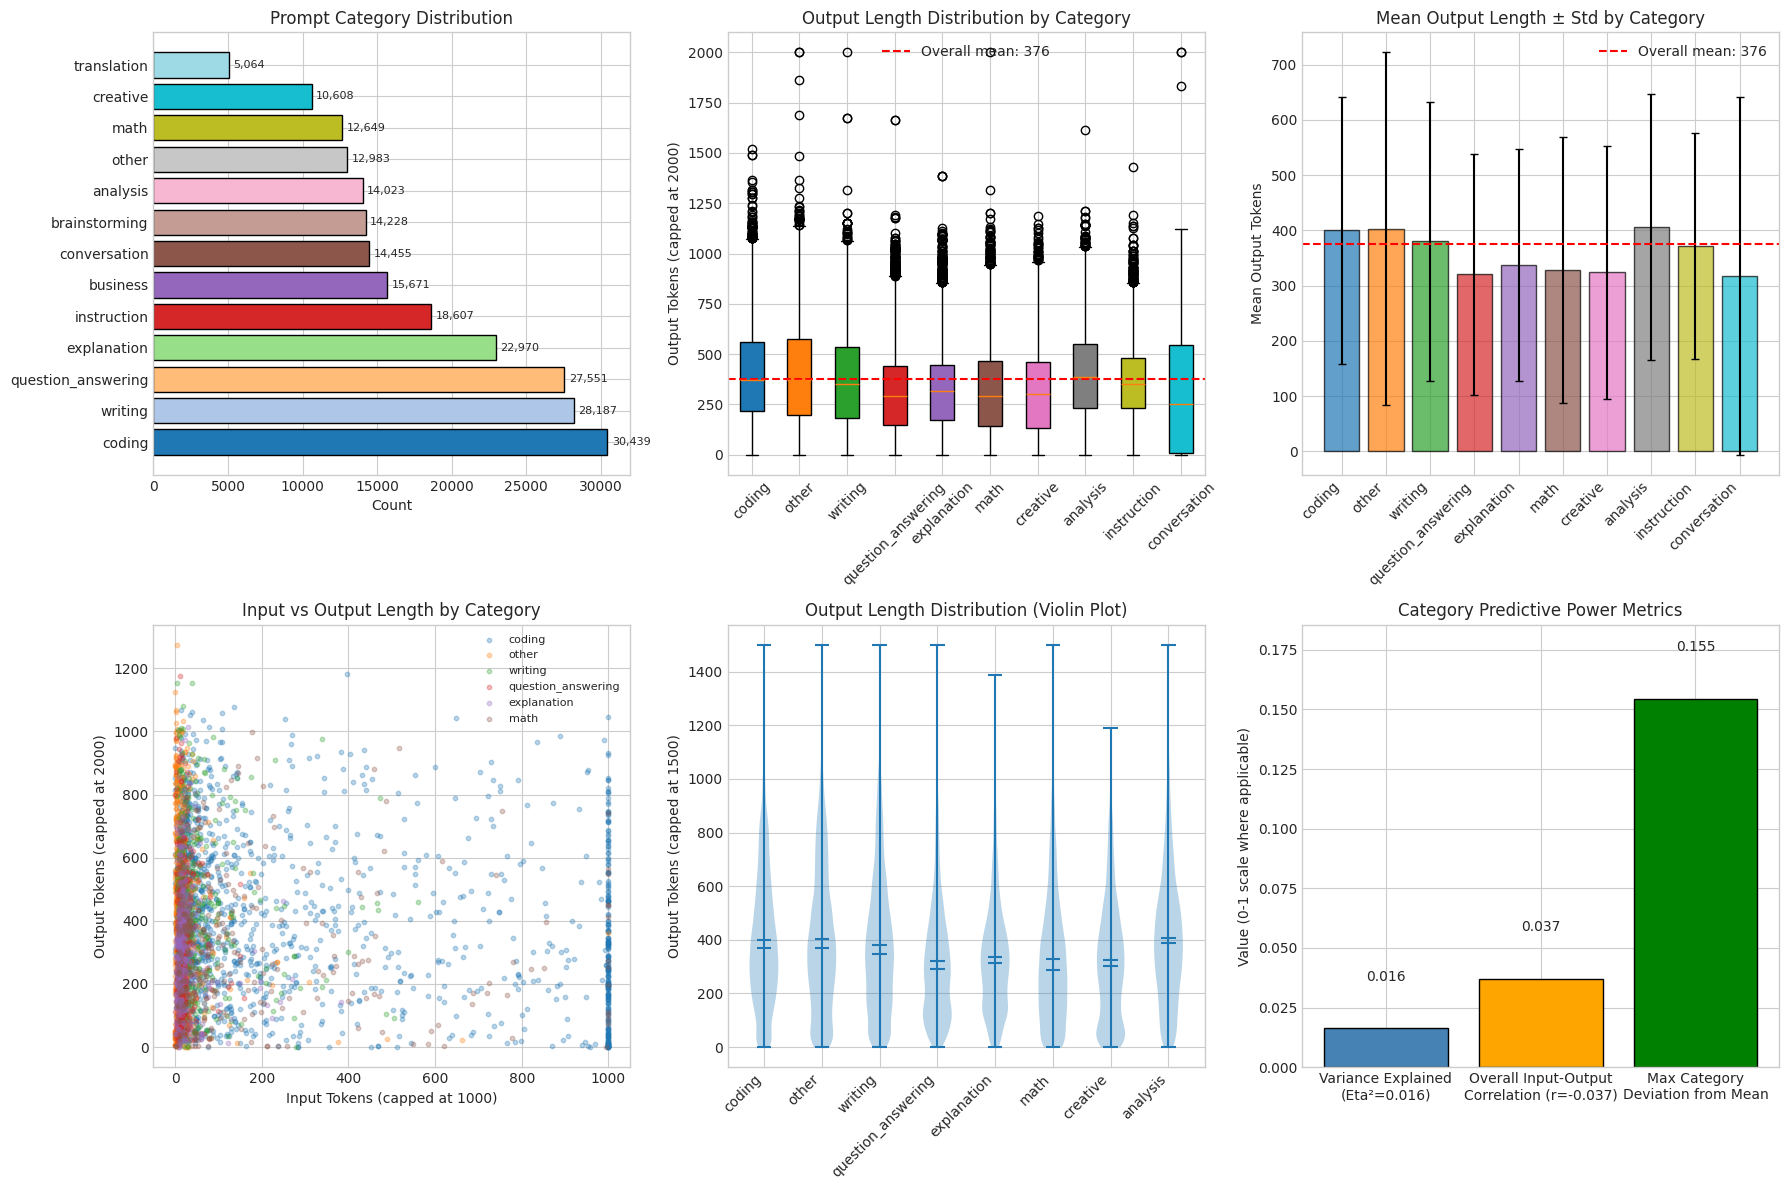


SUMMARY: IS CATEGORY USEFUL FOR OUTPUT LENGTH PREDICTION?

Key Findings:
1. Variance Explained (Eta²): 0.0163 (1.63%)
   - Category explains 1.6% of output length variance
   - Weak predictor

2. Category-wise Mean Differences:
   - Highest: analysis (406 tokens)
   - Lowest: conversation (318 tokens)
   - Range: 88 tokens

3. Within-Category Variance:
   - Categories reduce prediction uncertainty by 9.7% on average

4. Recommendation:
   Category has LIMITED usefulness; consider combining with other features
   - Best discriminating categories: 



In [7]:
# ============================================================
# CELL 4: IMPROVED PROMPT TYPE CLASSIFICATION + OUTPUT LENGTH PREDICTION
# ============================================================

# Enhanced patterns with more keywords per category
PROMPT_PATTERNS = {
    'coding': [
        # Languages
        r'\bpython\b', r'\bjavascript\b', r'\bjava\b', r'\bc\+\+\b', r'\bcpp\b', r'\bc#\b', 
        r'\bruby\b', r'\brust\b', r'\bgo\b', r'\bswift\b', r'\bkotlin\b', r'\bphp\b', 
        r'\btypescript\b', r'\bscala\b', r'\br\b(?=\s+code|\s+script|\s+function)',
        # Web technologies
        r'\bhtml\b', r'\bcss\b', r'\breact\b', r'\bangular\b', r'\bvue\b', r'\bnode\.?js\b',
        r'\bdjango\b', r'\bflask\b', r'\bfastapi\b', r'\bexpress\b',
        # Database
        r'\bsql\b', r'\bmysql\b', r'\bpostgres\b', r'\bmongodb\b', r'\bredis\b', r'\bdatabase\b',
        # Code concepts
        r'\bcode\b', r'\bprogram\b', r'\bfunction\b', r'\bscript\b', r'\bclass\b', r'\bmethod\b',
        r'\bapi\b', r'\bendpoint\b', r'\brest\b', r'\bgraphql\b',
        r'\bdebug\b', r'\berror\b', r'\bbug\b', r'\bexception\b', r'\bcrash\b', r'\bfix\b.*\bcode\b',
        r'\bcompile\b', r'\bsyntax\b', r'\bruntime\b', r'\bstack\s*trace\b',
        r'\bvariable\b', r'\barray\b', r'\bloop\b', r'\bif\s+statement\b', r'\balgorithm\b',
        r'\bregex\b', r'\bregexp\b', r'\bregular\s+expression\b',
        r'\bimport\b.*\bfrom\b', r'\brequire\b\s*\(', r'\binclude\b',
        r'```', r'\bdef\s+\w+\(', r'\bfunction\s+\w+\s*\(', r'\bclass\s+\w+',
        # DevOps/tools
        r'\bdocker\b', r'\bkubernetes\b', r'\bgit\b', r'\blinux\b', r'\bbash\b', r'\bshell\b',
        r'\baws\b', r'\bazure\b', r'\bgcp\b', r'\bcloud\b',
    ],
    'writing': [
        r'\bwrite\b', r'\bwriting\b', r'\bwriter\b', r'\bauthor\b',
        r'\bessay\b', r'\bstory\b', r'\bnarrative\b', r'\bnovel\b', r'\bpoem\b', r'\bpoetry\b',
        r'\barticle\b', r'\bblog\b', r'\bpost\b', r'\bcontent\b',
        r'\bemail\b', r'\bletter\b', r'\bmessage\b', r'\bcorrespondence\b',
        r'\bsummarize\b', r'\bsummary\b', r'\bsynopsis\b', r'\bbrief\b',
        r'\brewrite\b', r'\bparaphrase\b', r'\brephrase\b', r'\bedit\b.*\btext\b',
        r'\bdraft\b', r'\bcompose\b', r'\bproofread\b', r'\bgrammar\b',
        r'\bparagraph\b', r'\bsentence\b', r'\bintroduction\b', r'\bconclusion\b',
        r'\btone\b', r'\bformal\b.*\bwriting\b', r'\binformal\b.*\bwriting\b',
        r'\bcopy\b.*\bwriting\b', r'\bcopywriting\b',
        r'\bspeech\b', r'\bpresentation\b', r'\bslides\b',
        r'\bresume\b', r'\bcv\b', r'\bcover\s+letter\b',
    ],
    'explanation': [
        r'\bexplain\b', r'\bexplanation\b', r'\bunderstand\b', r'\bunderstanding\b',
        r'\bwhat\s+is\b', r'\bwhat\s+are\b', r'\bwhat\'s\b', r'\bwhats\b',
        r'\bhow\s+does\b', r'\bhow\s+do\b', r'\bhow\s+is\b',
        r'\bwhy\s+is\b', r'\bwhy\s+does\b', r'\bwhy\s+do\b', r'\bwhy\s+are\b',
        r'\bdescribe\b', r'\bdescription\b',
        r'\bdefine\b', r'\bdefinition\b', r'\bmeaning\b',
        r'\bdifference\s+between\b', r'\bcompare\b.*\band\b', r'\bvs\b', r'\bversus\b',
        r'\bin\s+simple\s+terms\b', r'\blayman\b', r'\beli5\b', r'\blike\s+i\'?m\s+\d+\b',
        r'\bconcept\b', r'\btheory\b', r'\bprinciple\b',
        r'\bwork\b.*\bunder\b.*\bhood\b', r'\bbehind\s+the\s+scenes\b',
        r'\bclarify\b', r'\belaborate\b', r'\bexpand\b.*\bon\b',
    ],
    'creative': [
        r'\bcreative\b', r'\bcreativity\b', r'\bimagine\b', r'\bimagination\b',
        r'\bfiction\b', r'\bfictional\b', r'\bmake\s+up\b', r'\binvent\b',
        r'\broleplay\b', r'\brole\s*play\b', r'\bact\s+as\b', r'\bpretend\b', r'\byou\s+are\s+a\b',
        r'\bgenerate\b.*\b(story|poem|idea|name|character)\b',
        r'\bbrainstorm\b', r'\bcome\s+up\s+with\b',
        r'\bcharacter\b', r'\bplot\b', r'\bsetting\b', r'\bscene\b',
        r'\bdialogue\b', r'\bconversation\b.*\bbetween\b',
        r'\bworldbuilding\b', r'\bworld\s+building\b', r'\bfantasy\b', r'\bsci-?fi\b',
        r'\bsong\b', r'\blyrics\b', r'\brhyme\b', r'\bverse\b',
        r'\bjoke\b', r'\bfunny\b', r'\bhumor\b', r'\bcomedy\b',
        r'\bgame\b.*\bidea\b', r'\bstory\s+prompt\b',
    ],
    'analysis': [
        r'\banalyze\b', r'\banalysis\b', r'\banalyse\b',
        r'\bevaluate\b', r'\bevaluation\b', r'\bassess\b', r'\bassessment\b',
        r'\breview\b', r'\bcritique\b', r'\bcritical\b',
        r'\bdata\b', r'\bdataset\b', r'\bstatistics\b', r'\bstatistical\b',
        r'\btrend\b', r'\bpattern\b', r'\binsight\b', r'\bfinding\b',
        r'\bchart\b', r'\bgraph\b', r'\bvisualization\b', r'\bplot\b.*\bdata\b',
        r'\bmetric\b', r'\bkpi\b', r'\bperformance\b',
        r'\bpros\s+and\s+cons\b', r'\badvantages\b.*\bdisadvantages\b', r'\bswot\b',
        r'\bstrength\b.*\bweakness\b', r'\bbenefit\b.*\bdrawback\b',
        r'\bcase\s+study\b', r'\bresearch\b', r'\bstudy\b',
        r'\bcompare\b', r'\bcomparison\b', r'\bbenchmark\b',
        r'\binterpret\b', r'\binterpretation\b',
    ],
    'question_answering': [
        r'^what\b', r'^who\b', r'^where\b', r'^when\b', r'^which\b',
        r'^how\s+(many|much|long|often|far)\b',
        r'^is\s+it\b', r'^is\s+there\b', r'^are\s+there\b', r'^does\b', r'^do\b', r'^did\b',
        r'^can\s+(i|you|we|it)\b', r'^could\b', r'^would\b', r'^should\b', r'^will\b',
        r'\?$',  # Ends with question mark
        r'\btell\s+me\b', r'\bdo\s+you\s+know\b', r'\bwhat\'s\s+the\b',
        r'\banyone\s+know\b', r'\bdoes\s+anyone\b',
    ],
    'translation': [
        r'\btranslate\b', r'\btranslation\b', r'\btranslator\b',
        r'\bin\s+english\b', r'\bto\s+english\b', r'\bfrom\s+english\b',
        r'\bin\s+spanish\b', r'\bin\s+french\b', r'\bin\s+german\b', r'\bin\s+chinese\b',
        r'\bin\s+japanese\b', r'\bin\s+korean\b', r'\bin\s+portuguese\b', r'\bin\s+italian\b',
        r'\bin\s+russian\b', r'\bin\s+arabic\b', r'\bin\s+hindi\b',
        r'\blanguage\b', r'\blanguages\b',
        r'\bconvert\b.*\bto\b.*\blanguage\b',
        r'\bforeign\b', r'\bnative\b.*\bspeaker\b',
        r'\blocalize\b', r'\blocalization\b',
    ],
    'math': [
        r'\bcalculate\b', r'\bcalculation\b', r'\bcompute\b', r'\bcomputation\b',
        r'\bsolve\b', r'\bsolution\b', r'\bsolving\b',
        r'\bequation\b', r'\bformula\b', r'\bexpression\b',
        r'\bmath\b', r'\bmathematics\b', r'\bmathematical\b',
        r'\balgebra\b', r'\bcalculus\b', r'\bgeometry\b', r'\btrigonometry\b',
        r'\bstatistics\b', r'\bprobability\b', r'\bpermutation\b', r'\bcombination\b',
        r'\bderivative\b', r'\bintegral\b', r'\blimit\b', r'\bmatrix\b',
        r'\bproof\b', r'\btheorem\b', r'\blemma\b',
        r'\d+\s*[\+\-\*\/\^]\s*\d+',  # Basic arithmetic
        r'\bpercentage\b', r'\bpercent\b', r'\bratio\b', r'\bfraction\b',
        r'\baverage\b', r'\bmean\b', r'\bmedian\b', r'\bmode\b', r'\bstandard\s+deviation\b',
        r'\bprime\b.*\bnumber\b', r'\bfactorial\b', r'\bfibonacci\b',
        r'\bword\s+problem\b', r'\bmath\s+problem\b',
    ],
    'instruction': [
        r'\bhow\s+to\b', r'\bhow\s+do\s+i\b', r'\bhow\s+can\s+i\b',
        r'\bsteps\b', r'\bstep[\s-]by[\s-]step\b', r'\bwalkthrough\b',
        r'\btutorial\b', r'\bguide\b', r'\bmanual\b', r'\bhandbook\b',
        r'\binstructions\b', r'\binstruction\b', r'\bdirections\b',
        r'\bteach\s+me\b', r'\bshow\s+me\b', r'\bhelp\s+me\b',
        r'\blearn\b', r'\blearning\b', r'\bbeginners?\b',
        r'\bsetup\b', r'\bset\s+up\b', r'\binstall\b', r'\bconfigure\b', r'\bconfiguration\b',
        r'\brecipe\b', r'\bprocess\b', r'\bprocedure\b', r'\bworkflow\b',
        r'\bbest\s+practice\b', r'\bbest\s+way\b',
        r'\btroublesho+t\b', r'\bfix\b', r'\bresolve\b',
    ],
    'brainstorming': [
        r'\bideas?\b', r'\bsuggestions?\b', r'\brecommend\b', r'\brecommendation\b',
        r'\badvice\b', r'\badvise\b', r'\btips?\b', r'\btricks?\b',
        r'\blist\b.*\b(some|top|best|ideas|ways|options)\b', r'\bgive\s+me\b.*\boptions\b',
        r'\balternatives?\b', r'\boptions?\b', r'\bchoices?\b',
        r'\bwhat\s+should\b', r'\bwhat\s+would\s+you\b',
        r'\bwhat\s+are\s+some\b', r'\bwhat\s+are\s+good\b',
        r'\bname\s+some\b', r'\bexamples?\b',
        r'\bhelp\s+me\s+(choose|decide|pick)\b', r'\bwhich\s+one\b.*\bbetter\b',
        r'\bpros\s+and\s+cons\b',
    ],
    'conversation': [
        r'^(hi|hello|hey|greetings|good\s+(morning|afternoon|evening))\b',
        r'\bhow\s+are\s+you\b', r'\bwhat\'s\s+up\b', r'\bwhats\s+up\b',
        r'\bthank\s*(you|s)\b', r'\bthanks\b', r'\bappreciate\b',
        r'\bbye\b', r'\bgoodbye\b', r'\bsee\s+you\b', r'\btake\s+care\b',
        r'\bsorry\b', r'\bapolog\b', r'\bexcuse\s+me\b',
        r'\bplease\b', r'\bcould\s+you\s+please\b', r'\bwould\s+you\s+mind\b',
        r'\bnice\s+to\s+meet\b', r'\bintroduce\b.*\bmyself\b',
        r'^(yes|no|ok|okay|sure|maybe|perhaps)\b',
        r'\bopinion\b', r'\bthink\s+about\b', r'\bfeel\s+about\b',
    ],
    'business': [
        r'\bbusiness\b', r'\bcompany\b', r'\bstartup\b', r'\bentrepreneu\b',
        r'\bmarketing\b', r'\badvertis\b', r'\bbrand\b', r'\bsales\b',
        r'\bstrategy\b', r'\bstrategic\b', r'\bplan\b.*\bbusiness\b',
        r'\binvestment\b', r'\binvest\b', r'\bfinance\b', r'\bfinancial\b',
        r'\bbudget\b', r'\brevenue\b', r'\bprofit\b', r'\bcost\b',
        r'\bmanagement\b', r'\bmanager\b', r'\bleadership\b', r'\bteam\b',
        r'\bcustomer\b', r'\bclient\b', r'\buser\s+experience\b', r'\bux\b',
        r'\bproduct\b', r'\bservice\b', r'\boffering\b',
        r'\bhr\b', r'\bhuman\s+resources\b', r'\bhiring\b', r'\brecruit\b',
        r'\bcontract\b', r'\bagreement\b', r'\bnegotiat\b',
    ],
}

def classify_prompt(text: str) -> List[str]:
    """Classify a prompt into one or more categories based on keyword matching."""
    text_lower = text.lower()
    cats = [cat for cat, patterns in PROMPT_PATTERNS.items() 
            if any(re.search(p, text_lower) for p in patterns)]
    return cats if cats else ['other']

def get_primary_category(cats: List[str]) -> str:
    """Get primary category with priority ordering."""
    priority = ['coding', 'math', 'translation', 'analysis', 'creative', 
                'writing', 'instruction', 'explanation', 'business',
                'brainstorming', 'question_answering', 'conversation', 'other']
    for p in priority:
        if p in cats:
            return p
    return cats[0] if cats else 'other'

# Classify all prompts and collect output length data
print("Classifying prompts with enhanced patterns...")
classification_data = []
prompt_categories = Counter()
multi_cat = 0

for s in tqdm(conv_stats, desc="Classifying"):
    if s['human_texts'] and s['gpt_texts']:
        # Use first turn for classification
        first_prompt = s['human_texts'][0]
        first_output = s['gpt_texts'][0]
        cats = classify_prompt(first_prompt)
        primary_cat = get_primary_category(cats)
        
        if len(cats) > 1: 
            multi_cat += 1
        for c in cats: 
            prompt_categories[c] += 1
        
        # Store data for output length analysis
        output_tokens = count_tokens(first_output)
        input_tokens = count_tokens(first_prompt)
        classification_data.append({
            'categories': cats,
            'primary_category': primary_cat,
            'input_tokens': input_tokens,
            'output_tokens': output_tokens,
            'total_gpt_tokens': s['gpt_token_total'],
            'num_turns': s['num_turns']
        })

total_prompts = len(conv_stats)
print("=" * 80)
print("PROMPT TYPE CLASSIFICATION (Enhanced)")
print("=" * 80)
print(f"Total: {total_prompts:,} | Multi-category: {multi_cat:,} ({multi_cat/total_prompts*100:.1f}%)")
print(f"\nCategory Distribution (prompts can have multiple categories):")
for cat, cnt in prompt_categories.most_common():
    print(f"  {cat:>20}: {cnt:>8,} ({cnt/total_prompts*100:>5.1f}%)")

# ============================================================
# OUTPUT LENGTH PREDICTION ANALYSIS BY CATEGORY
# ============================================================
print("\n" + "=" * 80)
print("OUTPUT LENGTH ANALYSIS BY CATEGORY")
print("=" * 80)

# Build DataFrame for analysis
clf_df = pd.DataFrame(classification_data)

# Aggregate stats by primary category
print("\n[OUTPUT LENGTH STATS BY PRIMARY CATEGORY]")
print(f"{'Category':<20} {'Count':>8} {'Mean Out':>10} {'Median':>10} {'Std':>10} {'P25':>8} {'P75':>8} {'P90':>8}")
print("-" * 96)

category_stats = {}
for cat in clf_df['primary_category'].unique():
    cat_data = clf_df[clf_df['primary_category'] == cat]['output_tokens']
    stats = {
        'count': len(cat_data),
        'mean': cat_data.mean(),
        'median': cat_data.median(),
        'std': cat_data.std(),
        'p25': cat_data.quantile(0.25),
        'p75': cat_data.quantile(0.75),
        'p90': cat_data.quantile(0.90)
    }
    category_stats[cat] = stats
    print(f"{cat:<20} {stats['count']:>8,} {stats['mean']:>10.1f} {stats['median']:>10.1f} "
          f"{stats['std']:>10.1f} {stats['p25']:>8.0f} {stats['p75']:>8.0f} {stats['p90']:>8.0f}")

# Overall stats for comparison
overall_mean = clf_df['output_tokens'].mean()
overall_std = clf_df['output_tokens'].std()
print(f"\n{'OVERALL':<20} {len(clf_df):>8,} {overall_mean:>10.1f} {clf_df['output_tokens'].median():>10.1f} "
      f"{overall_std:>10.1f} {clf_df['output_tokens'].quantile(0.25):>8.0f} "
      f"{clf_df['output_tokens'].quantile(0.75):>8.0f} {clf_df['output_tokens'].quantile(0.90):>8.0f}")

# ============================================================
# PREDICTIVE POWER ANALYSIS
# ============================================================
print("\n" + "=" * 80)
print("CATEGORY PREDICTIVE POWER FOR OUTPUT LENGTH")
print("=" * 80)

# Calculate variance explained (eta-squared)
from scipy import stats as scipy_stats

# Get groups for ANOVA
groups = [clf_df[clf_df['primary_category'] == cat]['output_tokens'].values 
          for cat in clf_df['primary_category'].unique() if len(clf_df[clf_df['primary_category'] == cat]) > 30]

if len(groups) >= 2:
    f_stat, p_value = scipy_stats.f_oneway(*groups)
    
    # Calculate eta-squared (variance explained)
    grand_mean = clf_df['output_tokens'].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((clf_df['output_tokens'] - grand_mean)**2)
    eta_squared = ss_between / ss_total
    
    print(f"\n[ANOVA Results]")
    print(f"F-statistic: {f_stat:.2f}")
    print(f"p-value: {p_value:.2e} {'(significant)' if p_value < 0.05 else '(not significant)'}")
    print(f"Eta-squared (variance explained): {eta_squared:.4f} ({eta_squared*100:.2f}%)")

# Calculate category deviation from overall mean
print(f"\n[CATEGORY DEVIATION FROM OVERALL MEAN ({overall_mean:.1f} tokens)]")
sorted_cats = sorted(category_stats.items(), key=lambda x: x[1]['mean'], reverse=True)
for cat, stats in sorted_cats:
    dev = stats['mean'] - overall_mean
    dev_pct = (dev / overall_mean) * 100
    print(f"  {cat:<20}: {stats['mean']:>7.1f} tokens ({dev:>+7.1f}, {dev_pct:>+6.1f}%)")

# Coefficient of variation within categories vs overall
print(f"\n[VARIANCE REDUCTION BY CATEGORY]")
overall_cv = overall_std / overall_mean  # Coefficient of variation
print(f"Overall CV (std/mean): {overall_cv:.3f}")
for cat, stats in sorted(category_stats.items(), key=lambda x: x[1]['count'], reverse=True)[:10]:
    if stats['mean'] > 0:
        cat_cv = stats['std'] / stats['mean']
        cv_reduction = (overall_cv - cat_cv) / overall_cv * 100
        print(f"  {cat:<20}: CV={cat_cv:.3f} ({cv_reduction:>+5.1f}% reduction)")

# ============================================================
# CORRELATION: INPUT LENGTH vs OUTPUT LENGTH BY CATEGORY
# ============================================================
print(f"\n[INPUT-OUTPUT LENGTH CORRELATION BY CATEGORY]")
print(f"{'Category':<20} {'Pearson r':>12} {'p-value':>12} {'Interpretation':<20}")
print("-" * 70)

for cat in sorted(category_stats.keys(), key=lambda x: category_stats[x]['count'], reverse=True)[:10]:
    cat_data = clf_df[clf_df['primary_category'] == cat]
    if len(cat_data) > 30:
        corr, p = scipy_stats.pearsonr(cat_data['input_tokens'], cat_data['output_tokens'])
        strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
        print(f"  {cat:<20} {corr:>10.3f} {p:>12.2e} {strength}")

overall_corr, _ = scipy_stats.pearsonr(clf_df['input_tokens'], clf_df['output_tokens'])
print(f"  {'OVERALL':<20} {overall_corr:>10.3f}")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Category distribution
ax1 = axes[0, 0]
sorted_cats_plot = sorted(prompt_categories.items(), key=lambda x: x[1], reverse=True)
cats, cnts = zip(*sorted_cats_plot)
colors = plt.cm.tab20(np.linspace(0, 1, len(cats)))
bars = ax1.barh(cats, cnts, color=colors, edgecolor='black')
for bar, cnt in zip(bars, cnts):
    ax1.text(bar.get_width() + max(cnts)*0.01, bar.get_y() + bar.get_height()/2, f'{cnt:,}', va='center', fontsize=8)
ax1.set_xlabel('Count')
ax1.set_title('Prompt Category Distribution')

# Plot 2: Output length by category (box plot)
ax2 = axes[0, 1]
cats_by_count = sorted(category_stats.keys(), key=lambda x: category_stats[x]['count'], reverse=True)[:10]
box_data = [clf_df[clf_df['primary_category'] == cat]['output_tokens'].clip(upper=2000).values for cat in cats_by_count]
bp = ax2.boxplot(box_data, labels=cats_by_count, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.tab10(np.linspace(0, 1, len(cats_by_count)))):
    patch.set_facecolor(color)
ax2.axhline(overall_mean, color='red', linestyle='--', label=f'Overall mean: {overall_mean:.0f}')
ax2.set_ylabel('Output Tokens (capped at 2000)')
ax2.set_title('Output Length Distribution by Category')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# Plot 3: Mean output length by category
ax3 = axes[0, 2]
means = [category_stats[cat]['mean'] for cat in cats_by_count]
stds = [category_stats[cat]['std'] for cat in cats_by_count]
x_pos = np.arange(len(cats_by_count))
bars = ax3.bar(x_pos, means, yerr=stds, capsize=3, color=plt.cm.tab10(np.linspace(0, 1, len(cats_by_count))), alpha=0.7, edgecolor='black')
ax3.axhline(overall_mean, color='red', linestyle='--', label=f'Overall mean: {overall_mean:.0f}')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(cats_by_count, rotation=45, ha='right')
ax3.set_ylabel('Mean Output Tokens')
ax3.set_title('Mean Output Length ± Std by Category')
ax3.legend()

# Plot 4: Input vs Output scatter by category (sample)
ax4 = axes[1, 0]
sample_df = clf_df.sample(n=min(5000, len(clf_df)), random_state=42)
for cat in cats_by_count[:6]:
    cat_sample = sample_df[sample_df['primary_category'] == cat]
    ax4.scatter(cat_sample['input_tokens'].clip(upper=1000), 
                cat_sample['output_tokens'].clip(upper=2000), 
                alpha=0.3, s=10, label=cat)
ax4.set_xlabel('Input Tokens (capped at 1000)')
ax4.set_ylabel('Output Tokens (capped at 2000)')
ax4.set_title('Input vs Output Length by Category')
ax4.legend(loc='upper right', fontsize=8)

# Plot 5: Violin plot for top categories
ax5 = axes[1, 1]
violin_data = [clf_df[clf_df['primary_category'] == cat]['output_tokens'].clip(upper=1500).values for cat in cats_by_count[:8]]
parts = ax5.violinplot(violin_data, positions=range(len(cats_by_count[:8])), showmeans=True, showmedians=True)
ax5.set_xticks(range(len(cats_by_count[:8])))
ax5.set_xticklabels(cats_by_count[:8], rotation=45, ha='right')
ax5.set_ylabel('Output Tokens (capped at 1500)')
ax5.set_title('Output Length Distribution (Violin Plot)')

# Plot 6: Category predictive power summary
ax6 = axes[1, 2]
if 'eta_squared' in dir():
    metrics = {
        f'Variance Explained\n(Eta²={eta_squared:.3f})': eta_squared,
        f'Overall Input-Output\nCorrelation (r={overall_corr:.3f})': abs(overall_corr),
        'Max Category\nDeviation from Mean': max(abs(s['mean'] - overall_mean)/overall_mean for s in category_stats.values())
    }
    bars = ax6.bar(metrics.keys(), metrics.values(), color=['steelblue', 'orange', 'green'], edgecolor='black')
    ax6.set_ylim(0, max(metrics.values()) * 1.2)
    ax6.set_ylabel('Value (0-1 scale where applicable)')
    ax6.set_title('Category Predictive Power Metrics')
    for bar, val in zip(bars, metrics.values()):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center')

plt.tight_layout()
plt.savefig('prompt_classification_output_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY AND RECOMMENDATIONS
# ============================================================
print("\n" + "=" * 80)
print("SUMMARY: IS CATEGORY USEFUL FOR OUTPUT LENGTH PREDICTION?")
print("=" * 80)

print(f"""
Key Findings:
1. Variance Explained (Eta²): {eta_squared:.4f} ({eta_squared*100:.2f}%)
   - Category explains {eta_squared*100:.1f}% of output length variance
   - {'Good predictor' if eta_squared > 0.1 else 'Moderate predictor' if eta_squared > 0.05 else 'Weak predictor'}

2. Category-wise Mean Differences:
   - Highest: {max(category_stats.items(), key=lambda x: x[1]['mean'])[0]} ({max(s['mean'] for s in category_stats.values()):.0f} tokens)
   - Lowest: {min(category_stats.items(), key=lambda x: x[1]['mean'])[0]} ({min(s['mean'] for s in category_stats.values()):.0f} tokens)
   - Range: {max(s['mean'] for s in category_stats.values()) - min(s['mean'] for s in category_stats.values()):.0f} tokens

3. Within-Category Variance:
   - Categories reduce prediction uncertainty by {np.mean([1 - (s['std']/overall_std) for s in category_stats.values() if s['std'] < overall_std])*100:.1f}% on average

4. Recommendation:
   {'Category IS useful as a feature for output length prediction' if eta_squared > 0.05 else 'Category has LIMITED usefulness; consider combining with other features'}
   - Best discriminating categories: {', '.join([cat for cat, s in category_stats.items() if abs(s['mean'] - overall_mean) > overall_std*0.3][:5])}
""")

In [6]:
# ============================================================
# CELL 5: EXPORT DETAILED STATISTICS FOR WORKLOAD GENERATION
# ============================================================
# This cell exports per-turn statistics needed to generate realistic workload files.
# Each row represents one LLM request (one turn in a conversation).

def export_workload_statistics(conv_stats: List[Dict], output_file: str = "sharedgpt_workload_stats.json"):
    """
    Export detailed per-turn statistics for workload generation.
    
    For each turn in each conversation, we save:
    - conversation_id: unique ID for the conversation
    - turn_number: 1, 2, 3, ... (which turn in the conversation)
    - num_turns_in_conv: total turns in this conversation
    - human_text: the human message at this turn
    - gpt_text: the GPT response at this turn
    - accumulated_prompt: full prompt sent to LLM (all history + current human msg)
    - prompt_tokens: token count of accumulated_prompt
    - output_tokens: token count of GPT response
    - prefix_tokens: tokens reusable from previous turn's KV cache
    - prefix_ratio: prefix_tokens / prompt_tokens
    - new_input_tokens: tokens of just the new human message
    """
    
    all_turns = []
    
    for conv_idx, stats in enumerate(tqdm(conv_stats, desc="Exporting")):
        conv_id = stats['id']
        messages = stats['all_messages']
        human_texts = stats['human_texts']
        gpt_texts = stats['gpt_texts']
        
        if len(messages) < 2:
            continue
        
        # Build accumulated prompts for each turn
        accumulated_prompt = ""
        accumulated_tokens = 0
        human_idx = 0
        gpt_idx = 0
        turn_number = 0
        
        prev_prompt_tokens = 0  # For prefix calculation
        
        i = 0
        while i < len(messages):
            msg = messages[i]
            role = msg.get('from', '')
            text = msg.get('value', '')
            tokens = count_tokens(text)
            
            if role == 'human':
                turn_number += 1
                
                # Build the prompt for this turn
                current_prompt = accumulated_prompt + text
                current_prompt_tokens = accumulated_tokens + tokens
                
                # Get the GPT response for this turn (if exists)
                gpt_response = ""
                gpt_response_tokens = 0
                if i + 1 < len(messages) and messages[i + 1].get('from') == 'gpt':
                    gpt_response = messages[i + 1].get('value', '')
                    gpt_response_tokens = count_tokens(gpt_response)
                
                # Calculate prefix (what's reusable from previous turn)
                # For turn 1: no prefix
                # For turn 2+: prefix = previous accumulated history
                if turn_number == 1:
                    prefix_tokens = 0
                    prefix_ratio = 0.0
                else:
                    # Prefix is everything before the new human message
                    prefix_tokens = accumulated_tokens
                    prefix_ratio = prefix_tokens / current_prompt_tokens if current_prompt_tokens > 0 else 0.0
                
                turn_data = {
                    "conversation_id": conv_id,
                    "conversation_idx": conv_idx,
                    "turn_number": turn_number,
                    "num_turns_in_conv": len(human_texts),
                    "human_text": text,
                    "gpt_text": gpt_response,
                    "accumulated_prompt": current_prompt,
                    "prompt_tokens": current_prompt_tokens,
                    "output_tokens": gpt_response_tokens,
                    "new_input_tokens": tokens,
                    "prefix_tokens": prefix_tokens,
                    "prefix_ratio": round(prefix_ratio, 4)
                }
                all_turns.append(turn_data)
                
                # Update accumulated for next turn (includes current human + gpt response)
                accumulated_prompt = current_prompt + gpt_response
                accumulated_tokens = current_prompt_tokens + gpt_response_tokens
                
                human_idx += 1
                
                # Skip the GPT message we already processed
                if i + 1 < len(messages) and messages[i + 1].get('from') == 'gpt':
                    i += 1
                    gpt_idx += 1
            
            i += 1
    
    # Save to JSON
    print(f"\nSaving {len(all_turns):,} turns to {output_file}...")
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(all_turns, f, indent=2, ensure_ascii=False)
    
    # Also save a compact version without the full text (for quick loading)
    compact_file = output_file.replace('.json', '_compact.json')
    compact_turns = [{k: v for k, v in t.items() if k not in ['human_text', 'gpt_text', 'accumulated_prompt']} 
                     for t in all_turns]
    with open(compact_file, 'w', encoding='utf-8') as f:
        json.dump(compact_turns, f, indent=2)
    
    print(f"Saved compact version to {compact_file}")
    
    # Print summary
    print(f"\n[EXPORT SUMMARY]")
    print(f"Total conversations: {len(set(t['conversation_id'] for t in all_turns)):,}")
    print(f"Total turns (LLM requests): {len(all_turns):,}")
    print(f"  Turn 1 requests: {sum(1 for t in all_turns if t['turn_number'] == 1):,}")
    print(f"  Turn 2+ requests: {sum(1 for t in all_turns if t['turn_number'] > 1):,}")
    
    # Stats by turn number
    print(f"\n[STATS BY TURN]")
    for turn in range(1, 6):
        turn_data = [t for t in all_turns if t['turn_number'] == turn]
        if turn_data:
            avg_prompt = np.mean([t['prompt_tokens'] for t in turn_data])
            avg_output = np.mean([t['output_tokens'] for t in turn_data])
            avg_prefix = np.mean([t['prefix_ratio'] for t in turn_data])
            print(f"  Turn {turn}: n={len(turn_data):,}, avg_prompt={avg_prompt:.0f}, avg_output={avg_output:.0f}, avg_prefix_ratio={avg_prefix:.3f}")
    
    return all_turns

# Run export
workload_stats = export_workload_statistics(conv_stats, "sharedgpt_workload_stats.json")
print("\nDone! Use 'generate_workload.py' to create workload JSONL files.")

Exporting:   0%|          | 0/94145 [00:00<?, ?it/s]

Exporting: 100%|██████████| 94145/94145 [00:03<00:00, 31208.34it/s]



Saving 333,937 turns to sharedgpt_workload_stats.json...
Saved compact version to sharedgpt_workload_stats_compact.json

[EXPORT SUMMARY]
Total conversations: 92,833
Total turns (LLM requests): 333,937
  Turn 1 requests: 92,833
  Turn 2+ requests: 241,104

[STATS BY TURN]
  Turn 1: n=92,833, avg_prompt=184, avg_output=348, avg_prefix_ratio=0.000
  Turn 2: n=69,263, avg_prompt=509, avg_output=357, avg_prefix_ratio=0.881
  Turn 3: n=53,210, avg_prompt=841, avg_output=347, avg_prefix_ratio=0.939
  Turn 4: n=38,998, avg_prompt=1104, avg_output=327, avg_prefix_ratio=0.959
  Turn 5: n=26,730, avg_prompt=1295, avg_output=301, avg_prefix_ratio=0.968

Done! Use 'generate_workload.py' to create workload JSONL files.
